In [9]:
import os
from dotenv import load_dotenv
load_dotenv()
kaggle = os.getenv("KAGGLE_API_TOKEN")

In [13]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

UnauthenticatedError: User is not authenticated

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train_data = pd.read_csv("train.csv")

In [3]:
train_data.head(10)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
5,5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,Male,High,No,0
6,6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,Other,Low,Yes,0
7,7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,Other,High,No,1
8,8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,Other,Medium,Yes,0
9,9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,Other,High,NaN,1


In [4]:
train_data.shape

(691369, 14)

In [5]:
train_data.dtypes

id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
addicted_label               int64
dtype: object

In [6]:
X = train_data.copy()

In [7]:
X.drop(columns = ["id"], inplace = True)

In [8]:
y = train_data["addicted_label"].copy() 

In [9]:
X.drop(columns = ["addicted_label"], inplace = True)

In [10]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      662440 non-null  float64
 1   daily_screen_time_hours  595515 non-null  float64
 2   social_media_hours       557374 non-null  float64
 3   gaming_hours             564548 non-null  float64
 4   work_study_hours         639851 non-null  float64
 5   sleep_hours              646889 non-null  float64
 6   notifications_per_day    623785 non-null  float64
 7   app_opens_per_day        610659 non-null  float64
 8   weekend_screen_time      579306 non-null  float64
 9   gender                   662335 non-null  str    
 10  stress_level             636221 non-null  str    
 11  academic_work_impact     647145 non-null  str    
dtypes: float64(9), str(3)
memory usage: 70.9 MB


In [11]:
# separating numerical and categorical columns
numerical_data = []
string_data = []

for col in X.columns: 
    if X[col].dtype != float: 
        string_data.append(col)
    else: 
        numerical_data.append(col)
print ('numerical_data: \n', numerical_data)
print ('string_data: \n', string_data)


numerical_data: 
 ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
string_data: 
 ['gender', 'stress_level', 'academic_work_impact']


### Implementing SimpleImputer

In [12]:
from sklearn.impute import SimpleImputer

# median - less sensative to outlier than mean
num_imputer = SimpleImputer(strategy= "median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X[numerical_data] = num_imputer.fit_transform(X[numerical_data])
X[string_data] = cat_imputer.fit_transform(X[string_data])


### First I need to do the label encoding as we  can't find the correlation until then
- In our case implementing the label encoding is not the best approach
- As it will lead to "Order" example : female = 0 , male =1 other =2  : according it might consider male > female


In [13]:
for col in string_data : 
    print(f"{col :} : \n {X[col].unique()}\n")

gender : 
 <ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

stress_level : 
 <ArrowStringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

academic_work_impact : 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str



In [14]:
X["academic_work_impact"] = X["academic_work_impact"].map({"No" : 0, "Yes" : 1})
X["stress_level"] = X["stress_level"].map({"Low" : 0, "Medium" : 1, "High" : 2})

In [15]:
X= pd.get_dummies(X, columns = ["gender"], dtype = int)

In [16]:
print(X.dtypes, "\n")# all numerical 
print(X.isnull().sum())


age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
stress_level                 int64
academic_work_impact         int64
gender_Female                int64
gender_Male                  int64
gender_Other                 int64
dtype: object 

age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
gender_Female              0
gender_Male                0
gender_Other               0
dtype: int64


In [17]:
train_data.columns

# we can create a function to check if the columns has strong correlation of 60% of features
# this condition can be implemented through a simple function
for col in train_data.columns :
    if train_data[col].dtype != object :
        print(f"{col} relation : \n {train_data.corr(numeric_only=True)[col]}\n")



id relation : 
 id                         1.000000
age                       -0.001002
daily_screen_time_hours    0.001297
social_media_hours         0.003168
gaming_hours              -0.002048
work_study_hours           0.000283
sleep_hours               -0.000918
notifications_per_day     -0.001197
app_opens_per_day         -0.000494
weekend_screen_time        0.002387
addicted_label             0.001097
Name: id, dtype: float64

age relation : 
 id                        -0.001002
age                        1.000000
daily_screen_time_hours    0.012901
social_media_hours         0.010899
gaming_hours               0.001687
work_study_hours           0.001091
sleep_hours                0.002214
notifications_per_day     -0.007039
app_opens_per_day          0.000592
weekend_screen_time        0.013044
addicted_label             0.004043
Name: age, dtype: float64

daily_screen_time_hours relation : 
 id                         0.001297
age                        0.012901
daily_screen_

KeyError: 'gender'

In [ ]:
train_data.isnull().sum()

id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64

In [ ]:
train_data.dtypes

id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
addicted_label               int64
dtype: object

In [ ]:
train_data["gender"].drop_duplicates()

In [67]:
train_data["gender"].unique()

<ArrowStringArray>
['Male', 'Female', 'Other', nan]
Length: 4, dtype: str

In [68]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
labelled = encoder.fit_transform(train_data[])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1792314075.py, line 3)

In [69]:
max(train_data.isnull().sum())/len(train_data)*100
# How does it will effect if we remove the 20% of columns
# Data loss = Low Variance


19.381111967704655

In [70]:
len(train_data)

691369

In [72]:
X.head(10)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other
0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1,0,0,1,0
1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,1,0,1,0,0
2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,0,1,1,0,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,0,1,0,0,1
4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,1,0,1,0,0
5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,2,0,0,1,0
6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,0,1,0,0,1
7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,104.0,13.45,2,0,0,0,1
8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,1,1,0,0,1
9,20.0,8.74,1.40,2.43,2.11,8.57,150.0,109.0,10.68,2,1,0,0,1


In [73]:
for col in X.columns:
    print(f"{col} : max : {X[col].max()}, min : {X[col].min()}")

age : max : 35.0, min : 18.0
daily_screen_time_hours : max : 15.0, min : 0.5
social_media_hours : max : 8.0, min : 0.0
gaming_hours : max : 4.0, min : 0.0
work_study_hours : max : 6.0, min : 0.0
sleep_hours : max : 9.0, min : 4.5
notifications_per_day : max : 250.0, min : 20.0
app_opens_per_day : max : 180.0, min : 15.0
weekend_screen_time : max : 17.56, min : 0.51
stress_level : max : 2, min : 0
academic_work_impact : max : 1, min : 0
gender_Female : max : 1, min : 0
gender_Male : max : 1, min : 0
gender_Other : max : 1, min : 0


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(type(X_scaled))

<class 'numpy.ndarray'>


In [19]:
X_scaled = pd.DataFrame(X_scaled, columns = X.columns, index = X.index)
X_scaled.describe().loc[["mean", "std"]]

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other
mean,-1.639440e-16,-1.692060e-16,2.681972e-16,-2.269234e-17,5.903298e-17,-2.538912e-16,1.022800e-16,-6.684375e-17,2.029156e-16,-7.251684e-17,6.186953e-17,5.331879e-17,2.137685e-17,-7.317459e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00


In [20]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)


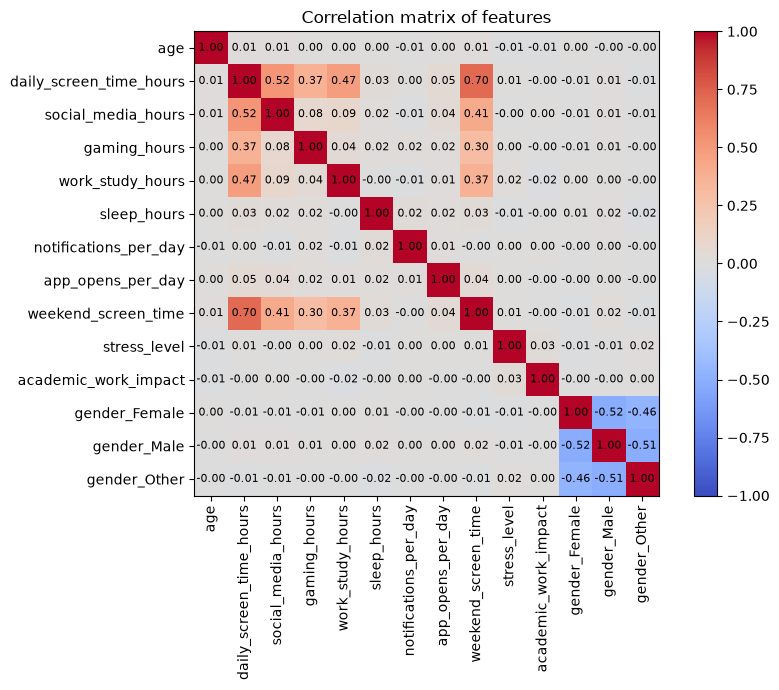

In [21]:
### heatmap of covariance matrix 
import matplotlib.pyplot as plt
cov = X_scaled.cov()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cov, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cov.columns)))
ax.set_yticks(range(len(cov.columns)))
ax.set_xticklabels(cov.columns, rotation=90)
ax.set_yticklabels(cov.columns)

# annotate each cell with its value
for i in range(len(cov.columns)):
    for j in range(len(cov.columns)):
        ax.text(j, i, f"{cov.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

fig.colorbar(im)
plt.title("Correlation matrix of features")
plt.tight_layout()
plt.show()

daily_screen_time_hours have correlated with many features (and all of them are high level) so it has the highest loading score in PC1. 

Same logic applied with other features, which explains why gaming_hours has lowest loading_score (except from the noise) since it less likely to correlate with other features. 



In [22]:
# Eigendecomposition of the covariance matrix — this is what PCA does internally
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# eigh returns ascending order; flip to descending (largest = PC1)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

loadings = pd.DataFrame(
    eigenvectors,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(len(X.columns))]
)
print(loadings.round(3))

                           PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
age                     -0.013 -0.005 -0.005 -0.058 -0.384  0.719  0.538   
daily_screen_time_hours -0.584 -0.019  0.001  0.016 -0.001 -0.019  0.014   
social_media_hours      -0.394 -0.006 -0.002 -0.018 -0.010  0.121 -0.066   
gaming_hours            -0.289 -0.009  0.007 -0.184  0.082 -0.097  0.211   
work_study_hours        -0.353 -0.027  0.002  0.218 -0.067 -0.102 -0.067   
sleep_hours             -0.028  0.032 -0.047 -0.612  0.066  0.029  0.049   
notifications_per_day    0.000  0.011  0.002 -0.494  0.340 -0.295  0.406   
app_opens_per_day       -0.051  0.008 -0.008 -0.404  0.179  0.488 -0.651   
weekend_screen_time     -0.539 -0.015  0.002  0.017 -0.004 -0.014  0.014   
stress_level            -0.009 -0.018  0.045  0.305  0.570  0.222  0.008   
academic_work_impact     0.008 -0.005  0.013  0.187  0.603  0.270  0.257   
gender_Female            0.013 -0.450 -0.684  0.014  0.020  0.000  0.002   
gender_Male 

In [38]:
print("per-component variance : \n", explained , "/n", len(explained))
print("\n Cumulative variance : \n", cumulative)


per-component variance : 
 [1.76687471e-01 1.09687263e-01 1.04741810e-01 7.46420794e-02
 7.39092875e-02 7.12309939e-02 7.06882172e-02 7.02275138e-02
 6.90567676e-02 6.74849720e-02 6.37292497e-02 3.12041176e-02
 1.67102574e-02 6.52427485e-15] /n 14

 Cumulative variance : 
 [0.17668747 0.28637473 0.39111654 0.46575862 0.53966791 0.6108989
 0.68158712 0.75181464 0.8208714  0.88835638 0.95208562 0.98328974
 1.         1.        ]


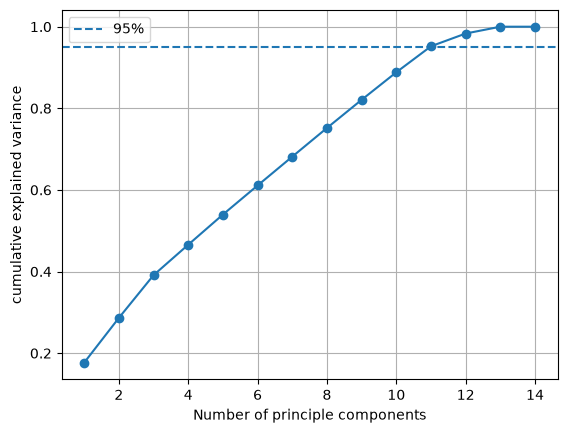

In [39]:
plt.plot(range(1, len(explained)+1), cumulative, marker ="o")
plt.axhline(0.95, linestyle = "--", label = "95%")
plt.xlabel("Number of principle components")
plt.ylabel("cumulative explained variance")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
X.columns

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'stress_level',
       'academic_work_impact', 'gender_Female', 'gender_Male', 'gender_Other'],
      dtype='object')

- Check can you remove all the 3 columns from the dataset and keep 11 columns
- or you need to add one more column as make them as 12 
daily_screen_time_hours, social_media_hours, weekend_screen_time

## Before vs After implement PCA

In [26]:
from sklearn.impute import SimpleImputer

test_data = pd.read_csv("test.csv")

# keep a copy of raw IDs if needed later
raw_test_id = test_data["id"].copy()

# same as train: remove id and prepare features
X_test = test_data.drop(columns=["id"]).copy()

# identify categorical vs numeric columns
numeric_cols = [col for col in X_test.columns if X_test[col].dtype in [np.float64, np.int64]]
string_cols = [col for col in X_test.columns if col not in numeric_cols]

# impute missing values using same strategy as train
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_test[numeric_cols] = num_imputer.fit_transform(X_test[numeric_cols])
X_test[string_cols] = cat_imputer.fit_transform(X_test[string_cols])

# encode binary/ordinal categorical values as in train
X_test["academic_work_impact"] = X_test["academic_work_impact"].map({"No": 0, "Yes": 1})
X_test["stress_level"] = X_test["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})

# one-hot encode gender, same as training
X_test = pd.get_dummies(X_test, columns=["gender"], dtype=int)

# align test columns to the exact train feature order and add missing columns as 0
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# optional: if you want scaled test data too
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_test.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other
0,30.0,9.34,2.32,0.77,4.09,7.15,153.0,16.0,9.58,1,1,0,0,1
1,27.0,7.77,1.91,1.33,1.20,8.67,239.0,148.0,10.68,2,0,1,0,0
2,26.0,8.48,3.64,1.33,3.39,7.47,106.0,123.0,9.58,2,0,0,1,0
3,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,2,1,0,1,0
4,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,0,0,0,1,0


In [27]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_scaled, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [28]:
### Predict 
preds = model.predict(X_test)                 # class labels (0/1)

In [32]:
y_truth = pd.read_csv('sample_submission.csv')
y_truth

,id,addicted_label
0,691369,0.709424
1,691370,0.709424
2,691371,0.709424
3,691372,0.709424
4,691373,0.709424
...,...,...
296297,987666,0.709424
296298,987667,0.709424
296299,987668,0.709424
296300,987669,0.709424


In [33]:
y_truth = y_truth.drop(columns = 'id')